In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
data = pd.read_csv("retail_fraud_detection_100k.csv")
data.head()

,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,...,failed_transaction_count_24h,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk
0,T0000001,C20953,2026-03-04 19:56:23.679173,56.31,Debit Card,Tablet,Canada,Fashion,0,13,...,4,1054,0,0,0,1,0,1,0,Medium
1,T0000002,C24133,2026-03-09 19:56:23.679330,20.35,Credit Card,Tablet,India,Electronics,0,3,...,2,97,0,0,0,0,0,0,0,Low
2,T0000003,C07165,2026-01-01 19:56:23.679362,48.72,Debit Card,Tablet,UK,Travel,0,8,...,4,779,1,0,0,0,0,0,0,Medium
3,T0000004,C19310,2025-12-09 19:56:23.679385,153.62,Debit Card,Mobile,Australia,Fashion,0,14,...,3,286,1,1,0,1,0,1,1,High
4,T0000005,C25019,2025-11-09 19:56:23.679409,115.32,PayPal,Mobile,India,Gaming,0,10,...,3,866,0,0,0,1,0,0,0,Low


In [2]:
num_data=data.select_dtypes(include=np.number)
cat_data=data.select_dtypes(exclude=np.number)

In [3]:
num_data.duplicated().sum()

np.int64(0)

In [4]:
cat_data.duplicated().sum()

np.int64(0)

In [5]:
num_data.head(2)

,transaction_amount,is_international,transaction_frequency_24h,avg_transaction_amount_7d,failed_transaction_count_24h,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag
0,56.31,0,13,53.02,4,1054,0,0,0,1,0,1,0
1,20.35,0,3,38.00,2,97,0,0,0,0,0,0,0


In [6]:
# import scipy.stats as stats
# for i in num_data.columns:
#     for j in num_data.columns:
#         if i!=j:
#             fraud=data[data[i]==1][j]
#             norm=data[data[i]==0][j]
#             z_criti,p_value=stats.ttest_ind(fraud,norm)
#             if(p_value < 0.05):
#                 print(p_value)
#                 print(f" This relation between {i} and {j}")

#                 print("Yes, there a relationship between them")

In [7]:
# import scipy.stats as stats
# for i in cat_data.columns:
#     for j in cat_data.columns:
#         if i!=j:
#             frauds=cat_data[cat_data[i]==1][j]
#             norms=cat_data[cat_data[i]==0][j]
#             z_criti,p_value=stats.ttest_ind(frauds,norms)
#             if(p_value < 0.05):
#                 print(p_value)
#                 print(f" This relation between {i} and {j}")

#                 print("Yes, there a relationship between them")

In [8]:
num_data.columns

Index(['transaction_amount', 'is_international', 'transaction_frequency_24h',
       'avg_transaction_amount_7d', 'failed_transaction_count_24h',
       'account_age_days', 'previous_fraud_flag', 'unusual_amount_flag',
       'unusual_location_flag', 'multiple_transactions_short_time',
       'high_risk_device_flag', 'velocity_flag', 'fraud_flag'],
      dtype='str')

In [9]:
num_data_=['transaction_amount', 'transaction_frequency_24h',
       'avg_transaction_amount_7d', 'failed_transaction_count_24h',
       'account_age_days']

# Numeric visualize

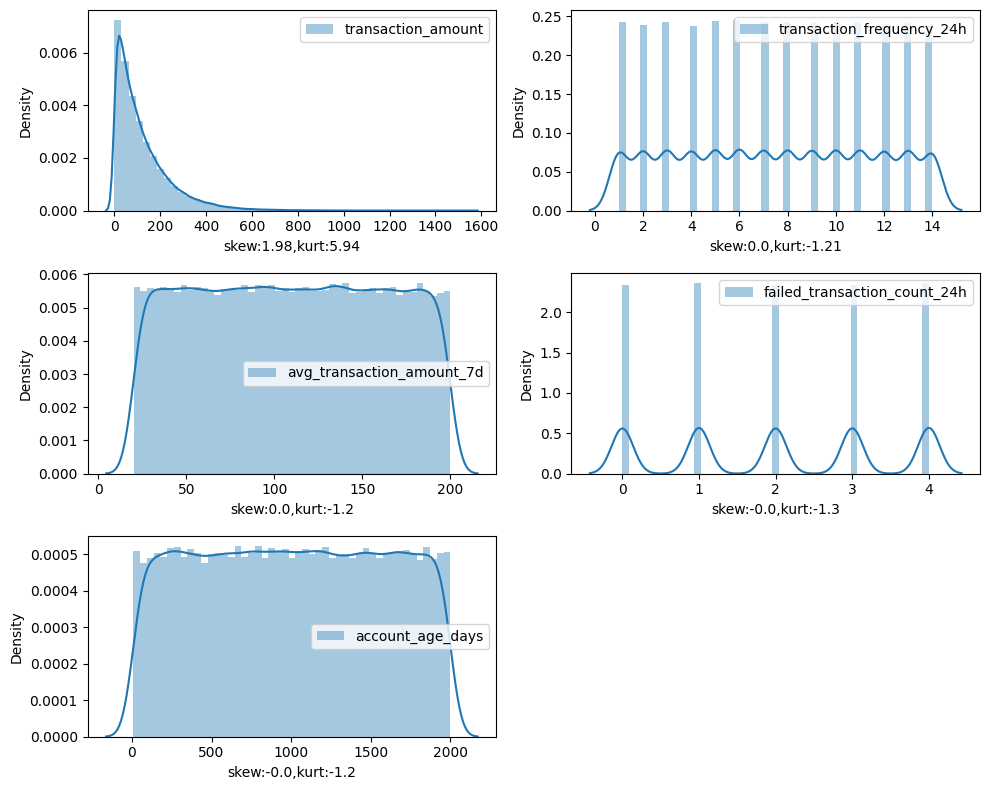

In [10]:
plt.figure(figsize=(10,8))
c=1
for i in num_data_:
    plt.subplot(3,2,c)
    sns.distplot(data[i],label=(i))
    plt.xlabel(f"skew:{np.round(data[i].skew(),2)},kurt:{np.round(data[i].kurt(),2)}")
    c+=1
    plt.legend()
plt.tight_layout()
plt.show()

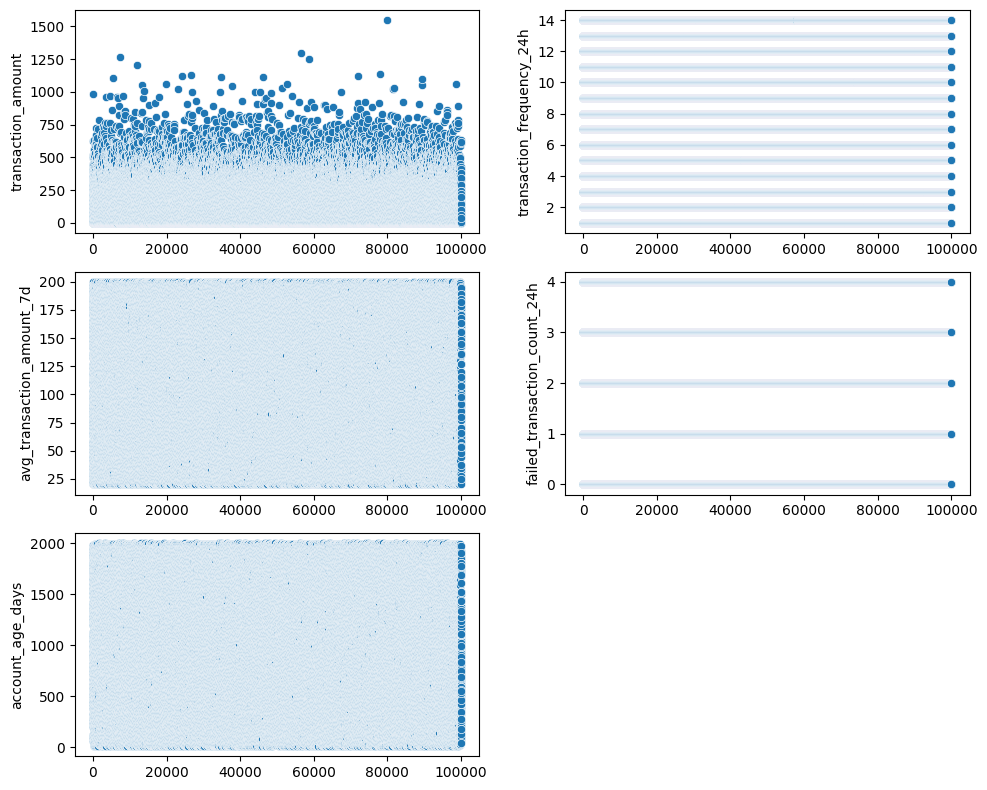

In [11]:
plt.figure(figsize=(10,8))
c=1
for i in num_data_:
    plt.subplot(3,2,c)
    sns.scatterplot(data[i])
    c+=1
    
plt.tight_layout()
plt.show()

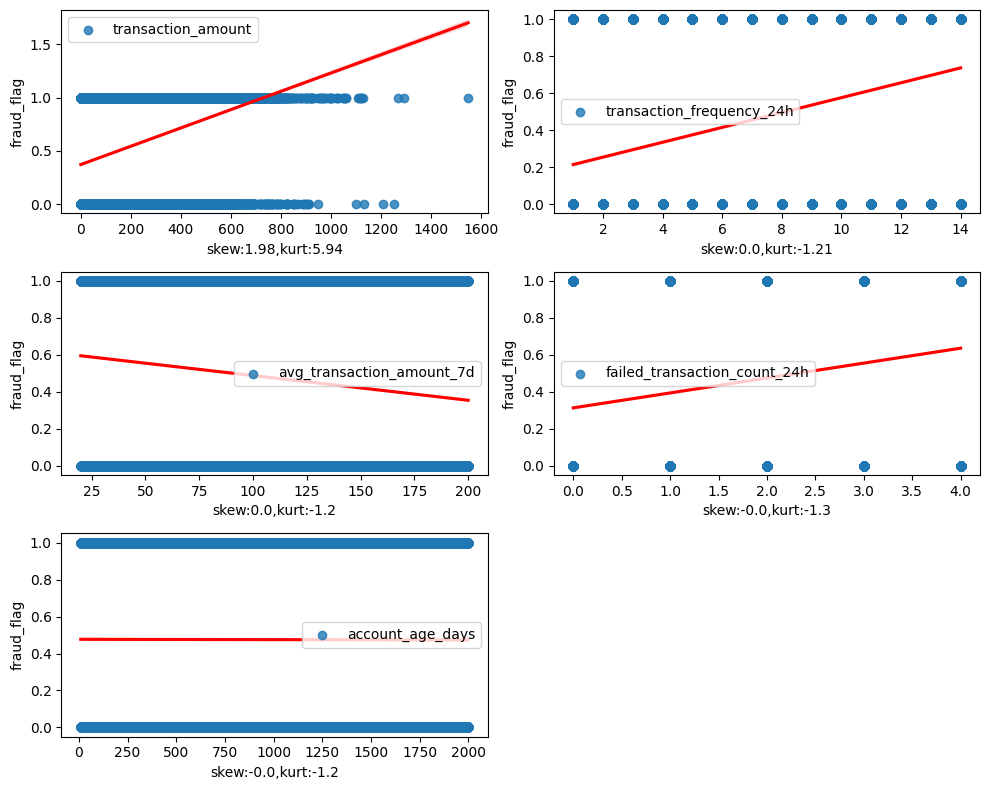

In [12]:
plt.figure(figsize=(10,8))
c=1
for i in num_data_:
    plt.subplot(3,2,c)
    sns.regplot(x=data[i],y=data['fraud_flag'],data=data,line_kws=({'color':'red'}),label=(i))
    plt.xlabel(f"skew:{np.round(data[i].skew(),2)},kurt:{np.round(data[i].kurt(),2)}")
    c+=1
    plt.legend()
plt.tight_layout()
plt.show()

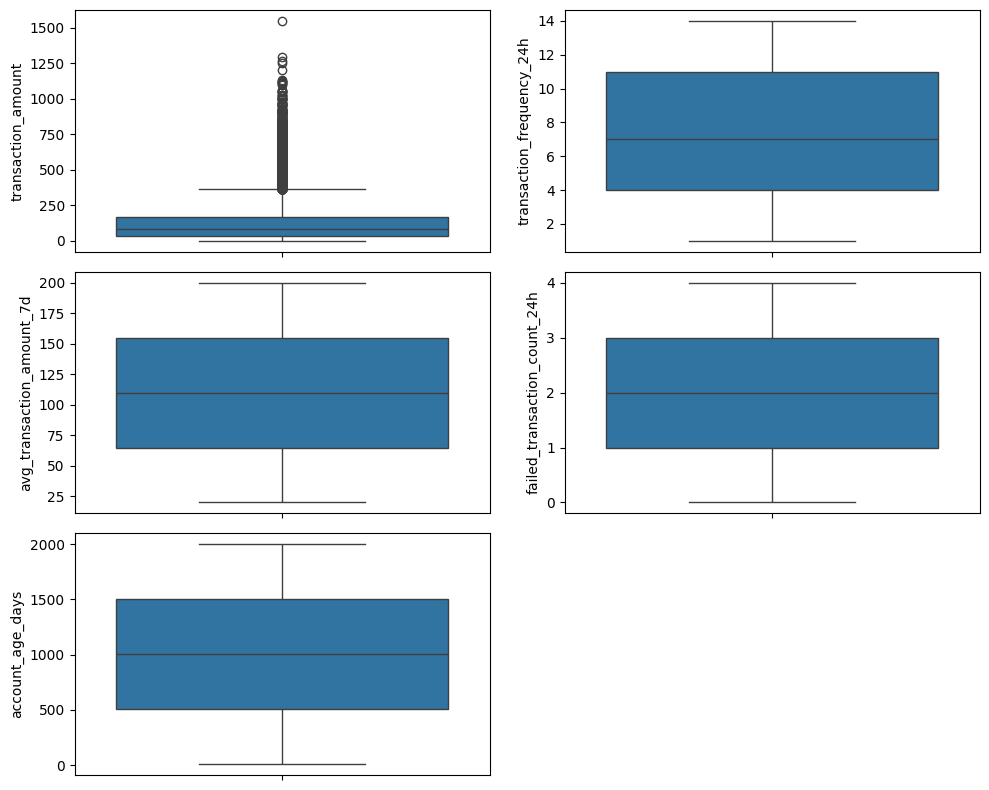

In [13]:
plt.figure(figsize=(10,8))
c=1
for i in num_data_:
    plt.subplot(3,2,c)
    sns.boxplot(data[i])
    c+=1
plt.tight_layout()
plt.show()

# Categorical Visualizing

In [14]:
cat_data_=[ 
       'payment_method', 'device_type', 'location', 'merchant_category',
       'fraud_risk']

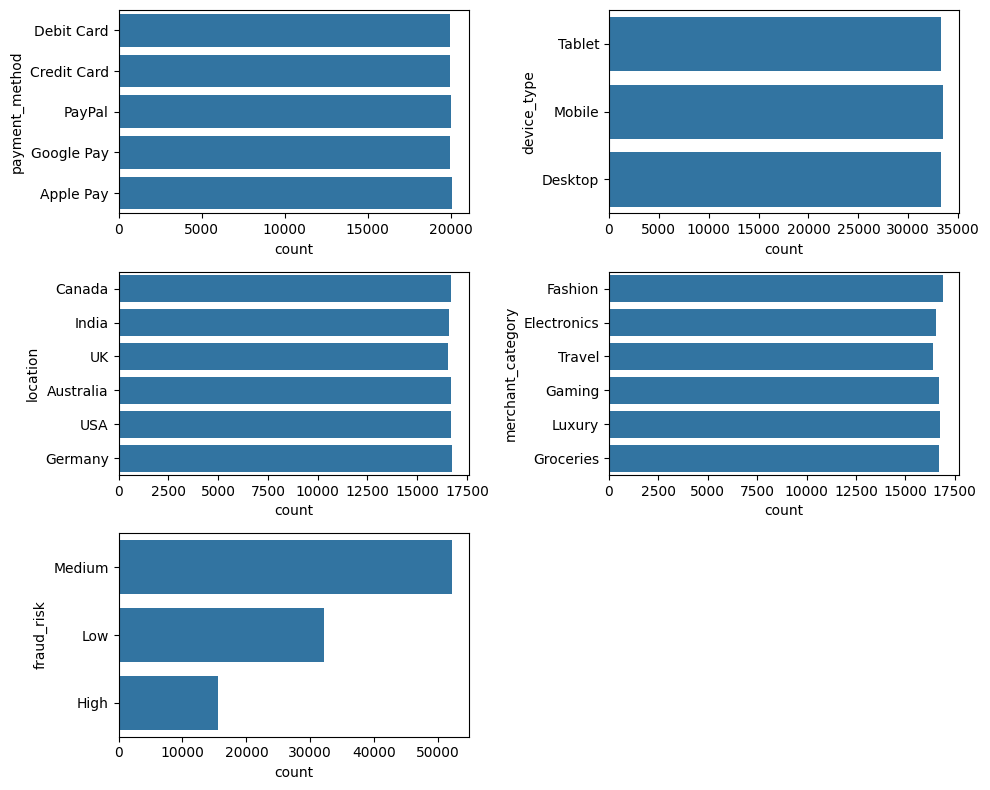

In [15]:
plt.figure(figsize=(10,8))
c=1
for i in cat_data_:
    plt.subplot(3,2,c)
    sns.countplot(data[i])
    c+=1
plt.tight_layout()
plt.show()

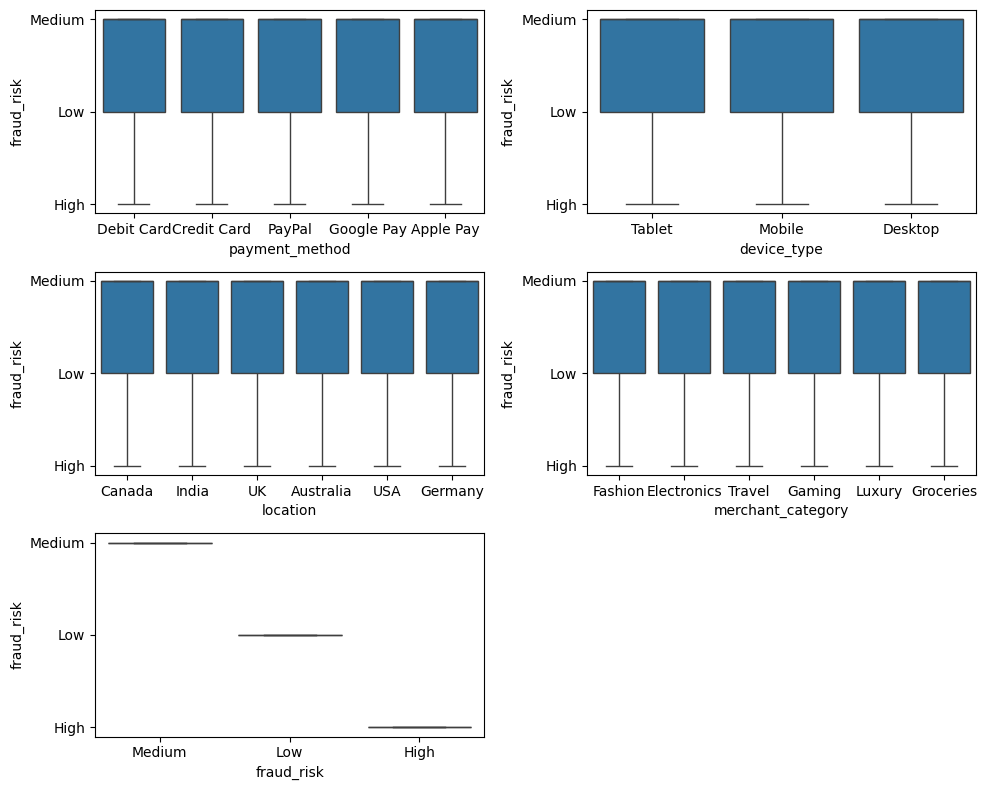

In [16]:
plt.figure(figsize=(10,8))
c=1
for i in cat_data_:
    plt.subplot(3,2,c)
    sns.boxplot(x=data[i],y=data['fraud_risk'],data=data)
    c+=1
plt.tight_layout()
plt.show()

In [17]:
data['device_type'].value_counts()

device_type
Mobile     33454
Desktop    33284
Tablet     33262
Name: count, dtype: int64

In [18]:
data['fraud_risk_label']=data['fraud_risk'].replace(to_replace=['Medium','Low','High'],value=[1,0,2])

In [19]:
data=data.drop(['transaction_id','customer_id','fraud_risk'],axis=1)

In [20]:
from sklearn.model_selection import StratifiedShuffleSplit

In [21]:
split=StratifiedShuffleSplit(n_splits=1,test_size=0.25,random_state=42)
for train,test in split.split(data,data['fraud_risk_label']):
    strat_train=data.loc[train]
    strat_test=data.loc[test]


In [22]:
train=strat_train.copy()
test=strat_test.copy()

In [23]:
train['fraud_risk_label']=train['fraud_risk_label'].astype(int)
test['fraud_risk_label']=test['fraud_risk_label'].astype(int)

In [24]:
train_label=train['fraud_risk_label']
train=train.drop('fraud_risk_label',axis=1)
test_label=test['fraud_risk_label']
test=test.drop('fraud_risk_label',axis=1)

In [25]:
train.head(1)

,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,avg_transaction_amount_7d,failed_transaction_count_24h,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag
77930,2025-06-08 19:56:25.311859,51.55,Apple Pay,Mobile,Canada,Gaming,1,9,102.97,3,246,0,0,1,1,0,0,1


In [26]:
un_fre_inter=train.groupby('is_international')['transaction_frequency_24h'].mean()
doubt_trans=train.groupby('unusual_amount_flag')['transaction_amount'].mean()
high_risk_faild_trans=train.groupby('high_risk_device_flag')['failed_transaction_count_24h'].mean()
unusal_train_7d=train.groupby('unusual_amount_flag')['avg_transaction_amount_7d'].mean()

In [27]:
# Train data feature making
# train['speed_mult_trans']=train['multiple_transactions_short_time']*train['velocity_flag']
#Test data feature making
# test['speed_mult_trans']=train['multiple_transactions_short_time']*train['velocity_flag']

In [28]:
# Train data feature making
# train['un_fre_inter']=train['is_international'].map(un_fre_inter)
# train['doubt_trans']=train['unusual_amount_flag'].map(doubt_trans)
#Test data feature making
# test['un_fre_inter']=test['is_international'].map(un_fre_inter)
# test['doubt_trans']=test['unusual_amount_flag'].map(doubt_trans)

In [29]:
drop=['transaction_amount','is_international','previous_fraud_flag','high_risk_device_flag','transaction_frequency_24h','avg_transaction_amount_7d','account_age_days','fraud_flag','transaction_timestamp','payment_method','location','merchant_category']
train=train.drop(drop,axis=1)
test=test.drop(drop,axis=1)

In [30]:
num_train=train.select_dtypes(include=np.number)
cat_train=train.select_dtypes(exclude=np.number)

In [31]:
# import scipy.stats as stats
# for i in num_train.columns:
#     for j in num_train.columns:
#         if i!=j:
#             fraud=num_train[num_train[i]==1][j]
#             norm=num_train[num_train[i]==0][j]
#             z_criti,p_value=stats.ttest_ind(fraud,norm)
#             if(p_value < 0.05):
#                 print(p_value)
#                 print(f" This relation between {i} and {j}")

#                 print("Yes, there a relationship between them")

In [32]:
for i in num_train:
    q1,q3=np.quantile(train[i],[0.25,0.75])
    iqr=q3-q1
    ul=q3+(1.5*iqr)
    ll=q1-(1.5*iqr)
    ll,ul=np.quantile(train[i],[0.10,0.85])
    train.loc[train[i]>ul,i]=ul
    train.loc[train[i]<ll,i]=ll

In [33]:
cat_train.head()

,device_type
77930,Mobile
92199,Desktop
96736,Tablet
33879,Mobile
17042,Mobile


# Assumptions Handling

In [34]:
import statsmodels.stats.api as ssa
import statsmodels.api as sma
ols_model=sma.OLS(train_label,sma.add_constant(num_train)).fit()
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       fraud_risk_label   R-squared:                       0.600
Model:                            OLS   Adj. R-squared:                  0.600
Method:                 Least Squares   F-statistic:                 2.250e+04
Date:                Mon, 28 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:41:28   Log-Likelihood:                -42141.
No. Observations:               75000   AIC:                         8.429e+04
Df Residuals:                   74994   BIC:                         8.435e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                               -0.1159      0.003    -33.279      0.000      -0.123      -0.109
failed_transaction_count_24h         0.1466      0.001    133.849      0.000       0.144       0.149
unusual_amount_flag                  0.6092      0.004    165.406      0.000       0.602       0.616
unusual_location_flag                0.6020      0.003    194.197      0.000       0.596       0.608
multiple_transactions_short_time     0.3080      0.005     67.277      0.000       0.299       0.317
velocity_flag                        0.2983      0.005     59.362      0.000       0.288       0.308
==============================================================================
Omnibus:                     3361.402   Durbin-Watson:                   1.982
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1402.981
Skew:                           0.044   Prob(JB):                    2.22e-305
Kurtosis:                       2.336   Cond. No.                         11.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [35]:
# Linearity 
# esme p_value>0.05 honi chahiye esme phle f-test or dusra p_value h 
ssa.linear_rainbow(ols_model)

(np.float64(0.9962121000981449), np.float64(0.6433550474792918))

In [36]:
num_cor=train.select_dtypes(include=np.number)

In [37]:
#multicorealtion

corr=num_cor.corr()


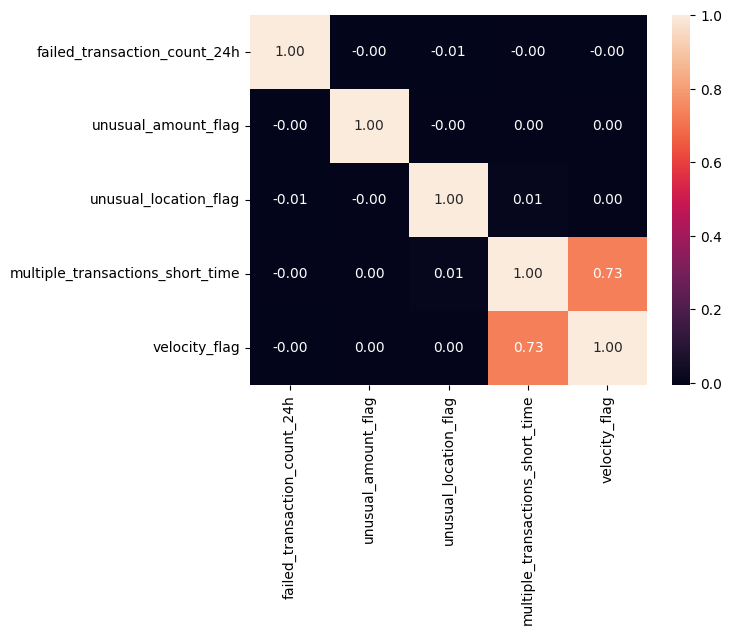

<Figure size 640x480 with 0 Axes>

In [38]:
sns.heatmap(corr,annot=True,fmt='0.2f')
plt.show()
plt.tight_layout()

In [39]:
# Varience Infaltion Factor(VIF)
#esme 10  se vif neeche rhna chahiye jiska uper ho uper pachucha do
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_list=[]
for i in range(num_train.shape[1]):
    vif_list.append(variance_inflation_factor(num_train.values,i))
vif=pd.DataFrame({"Feature":num_train.columns,'vif':vif_list})
vif.sort_values(ascending=False,by='vif')

,Feature,vif
3,multiple_transactions_short_time,3.476055
4,velocity_flag,2.977486
0,failed_transaction_count_24h,1.799085
2,unusual_location_flag,1.600019
1,unusual_amount_flag,1.221207


# AutoCorrelation

In [40]:
from statsmodels.stats.stattools import durbin_watson

In [41]:
# agar value 1.5 se 2.5 ke beech best or 1 se 4 ke beech normal eske alawa wrost
durbin_watson(ols_model.resid)

np.float64(1.9821683025470287)

# Hetrodascasity

In [42]:
ssa.het_breuschpagan(ols_model.resid,sma.add_constant(ols_model.model.exog))

(np.float64(611.0841713016513),
 np.float64(8.144396452267432e-130),
 np.float64(123.21095376124968),
 np.float64(2.3874237680620986e-130))

# Categorical feature selection 

In [43]:
# here i am using chi squared rule (esme use hi rakhna h jiski value p_value<0.05)
from scipy.stats import chi2_contingency
for i in cat_train.columns:
    table=pd.crosstab(train[i],train_label)
    _,p_value,_,_=chi2_contingency(table)
    print(p_value , i)

8.740306996194702e-83 device_type


# Feature Selection

In [44]:
from sklearn.ensemble import RandomForestClassifier
random=RandomForestClassifier()

In [45]:
from mlxtend.feature_selection import SequentialFeatureSelector
features=SequentialFeatureSelector(estimator=random,k_features='best',forward=True,scoring='neg_mean_squared_error')
features=features.fit(num_train,train_label)
print(features.k_feature_names_)

('failed_transaction_count_24h', 'unusual_amount_flag', 'unusual_location_flag', 'multiple_transactions_short_time')


In [46]:
from sklearn.feature_selection import RFE
feature=RFE(estimator=random,n_features_to_select=4)
feature=feature.fit(num_train,train_label)
pd.Series(feature.ranking_,index=num_train.columns).sort_values()

failed_transaction_count_24h        1
unusual_amount_flag                 1
unusual_location_flag               1
multiple_transactions_short_time    1
velocity_flag                       2
dtype: int64

In [47]:
train.head()

,device_type,failed_transaction_count_24h,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,velocity_flag
77930,Mobile,3,0,1,1,0
92199,Desktop,0,0,1,0,0
96736,Tablet,3,0,1,0,0
33879,Mobile,1,1,0,0,0
17042,Mobile,1,0,1,0,0


In [48]:
from sklearn.preprocessing import LabelEncoder,StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score,auc,precision_recall_curve,confusion_matrix,classification_report
from sklearn.model_selection import GridSearchCV,cross_val_score

# Machine learning apporach

In [49]:
num_pipeline=Pipeline([('impute',SimpleImputer(strategy='median')),('scaler',StandardScaler())])
cat_pipeline=Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('encoder',OneHotEncoder(handle_unknown='ignore'))])
merge_pipeline=ColumnTransformer([
    ('num_data',num_pipeline,list(num_train.columns)),
    ('cat_data',cat_pipeline,list(cat_train.columns))])
prepared=merge_pipeline.fit_transform(train,train_label)
prepared_test=merge_pipeline.transform(test)

In [50]:
random_model=RandomForestClassifier(n_estimators=150,max_depth=5,class_weight='balanced',min_samples_leaf=50,random_state=42,n_jobs=-1)
random_prepared=random_model.fit(prepared,train_label)
prediction=random_prepared.predict(prepared_test)

In [51]:
full_prepared=Pipeline([
    ('preprocessing',merge_pipeline),('rm_model',random_model)])

In [52]:
scoring=cross_val_score(full_prepared,train,train_label,cv=5,scoring='recall_weighted',n_jobs=-1)
scoring=(np.sum(scoring)/len(scoring))*100
print(scoring)


70.03866666666667


In [53]:
report=classification_report(test_label,prediction)
print(report)

              precision    recall  f1-score   support

           0       0.64      0.93      0.76      8051
           1       0.88      0.49      0.63     13053
           2       0.59      0.92      0.72      3896

    accuracy                           0.70     25000
   macro avg       0.70      0.78      0.70     25000
weighted avg       0.76      0.70      0.68     25000



In [54]:
accu=accuracy_score(test_label,prediction)
print('random forest model accuracy is :',accu*100)

random forest model accuracy is : 69.82000000000001


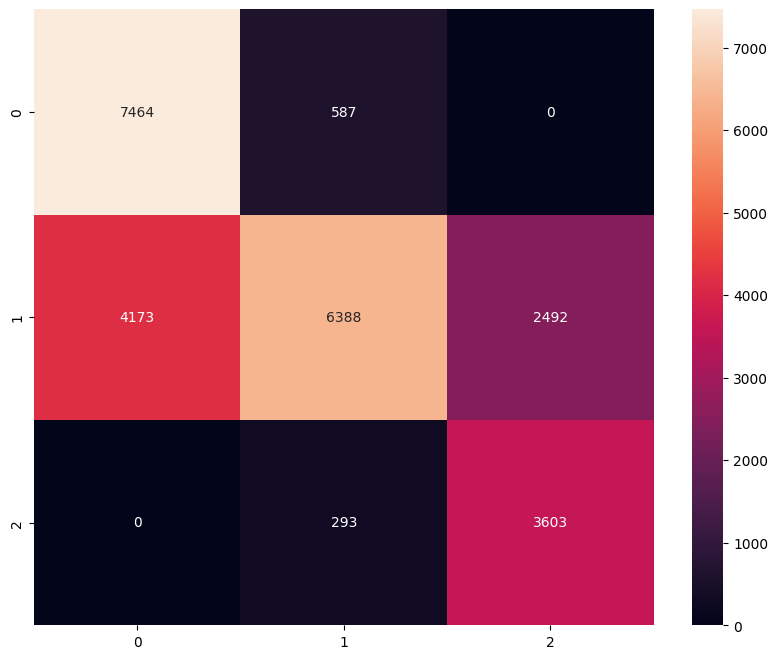

In [55]:
matrix=confusion_matrix(test_label,prediction)
plt.figure(figsize=(10,8))
sns.heatmap(matrix,annot=True,fmt='d')
plt.show()

In [56]:
# Here i am calculating pr-auc
y_random_prob=random_model.predict_proba(prepared_test)[:,2]
x_random_prob=(test_label==2)
precision_rand,recall_rand,_=precision_recall_curve(x_random_prob,y_random_prob)
auc_accuracy=auc(recall_rand,precision_rand)
print(auc_accuracy)

0.7547748626460292


In [1]:
num_train.head()

NameError: name 'num_train' is not defined

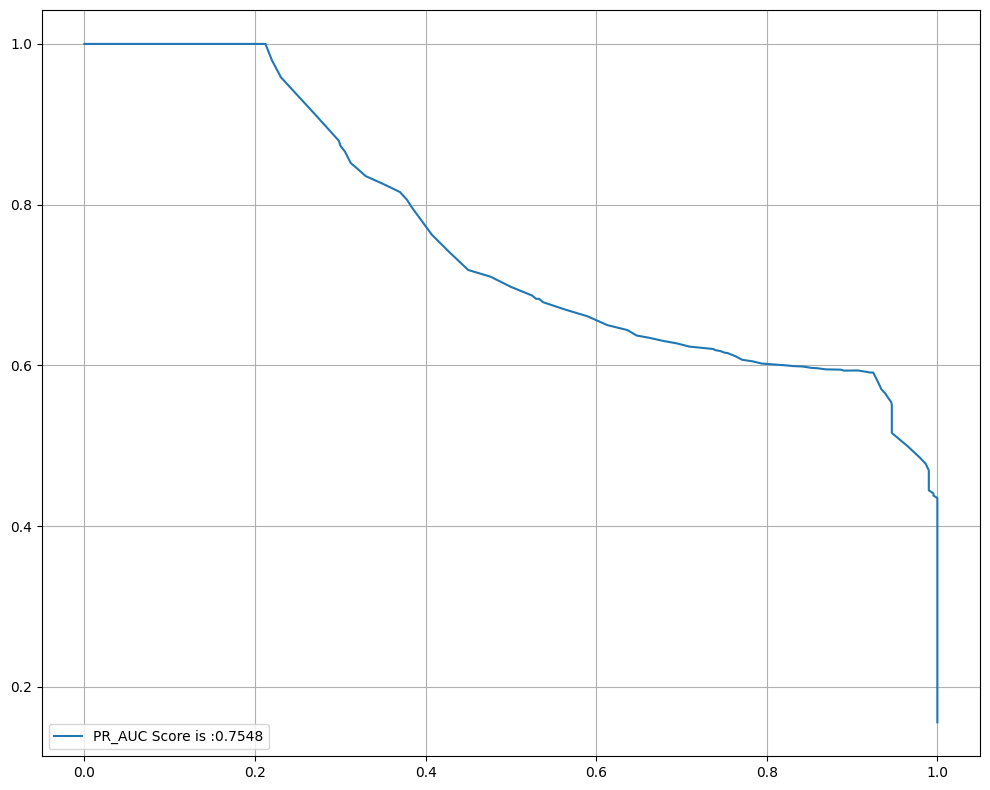

In [57]:
plt.figure(figsize=(10,8))
plt.plot(recall_rand,precision_rand,label=(f"PR_AUC Score is :{auc_accuracy:0.4f}"))
plt.legend(loc='lower left')
plt.grid()
plt.tight_layout()
plt.show()

In [58]:
# Feature Importance
values=random_prepared.feature_importances_
feature=merge_pipeline.get_feature_names_out()
importance=pd.DataFrame({"feature":feature,'value':values}).sort_values(by='value',ascending=False)
print(importance)

                                      feature     value
2             num_data__unusual_location_flag  0.307255
1               num_data__unusual_amount_flag  0.232623
0      num_data__failed_transaction_count_24h  0.171369
3  num_data__multiple_transactions_short_time  0.157614
4                     num_data__velocity_flag  0.120495
6                cat_data__device_type_Mobile  0.007097
5               cat_data__device_type_Desktop  0.001840
7                cat_data__device_type_Tablet  0.001706


In [61]:
parameter={
    'n_estimators':[50,100,150,200],
    'max_depth':[1,5,7,10,13,15,20],
    'min_samples_leaf':[20,30,40,50,60,70]}
search=GridSearchCV(random_model,param_grid=parameter,cv=4,scoring='recall_weighted',n_jobs=-1)
searching=search.fit(prepared,train_label)
print(searching.best_params_)


KeyboardInterrupt


KeyboardInterrupt



In [59]:
# prevous_fraud_flag feature is the game changer